# Market Basket Analysis
### Association Rule Mining with Apriori + RFM Customer Segmentation
**Dataset:** UCI Online Retail II (2009-2011)

## Step 1 - Install & Load Dataset

In [1]:
#!pip install mlxtend openpyxl -q

In [2]:
import sys
print(sys.executable)

C:\Users\Abdullah\anaconda3\envs\ml_env\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [4]:
file="online_retail_II.xlsx"

df_2009 = pd.read_excel(file, sheet_name='Year 2009-2010', engine='openpyxl')
df_2010 = pd.read_excel(file, sheet_name='Year 2010-2011', engine='openpyxl')
df = pd.concat([df_2009, df_2010], ignore_index=True)

In [5]:
df.shape

(1067371, 8)

In [6]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [7]:
print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Step 2 - Data Cleaning

In [9]:
print('Nulls before cleaning:')
print(df.isnull().sum())

df.dropna(subset=['Customer ID', 'Description'], inplace=True)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Description'] = df['Description'].str.strip().str.upper()
df['TotalPrice'] = df['Quantity'] * df['Price']

print('Shape after cleaning:', df.shape)
print('Unique customers:', df['Customer ID'].nunique())
print('Unique products:', df['Description'].nunique())
print('Unique invoices:', df['Invoice'].nunique())

Nulls before cleaning:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
Shape after cleaning: (805549, 9)
Unique customers: 5878
Unique products: 5240
Unique invoices: 36969


## Step 3 - RFM Customer Segmentation [Gap 3((No Segmentation): CustomerID column enables RFM-based customer )]
### RFM scoring → High / Medium / Low Value segments + 3 charts

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 3, labels=[3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1, 2, 3]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 3, labels=[1, 2, 3]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def assign_segment(score):
    if score >= 8:
        return 'High Value'
    elif score >= 5:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

print(rfm['Segment'].value_counts())
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment']].head(10)

Segment
Medium Value    2422
High Value      1742
Low Value       1714
Name: count, dtype: int64


,Customer ID,Recency,Frequency,Monetary,RFM_Score,Segment
0,12346,326,12,77556.46,7,Medium Value
1,12347,2,8,5633.32,9,High Value
2,12348,75,5,2019.40,7,Medium Value
3,12349,19,4,4428.69,8,High Value
4,12350,310,1,334.40,3,Low Value
5,12351,375,1,300.93,3,Low Value
6,12352,36,10,2849.84,9,High Value
7,12353,204,2,406.76,4,Low Value
8,12354,232,1,1079.40,5,Medium Value
9,12355,214,2,947.61,5,Medium Value


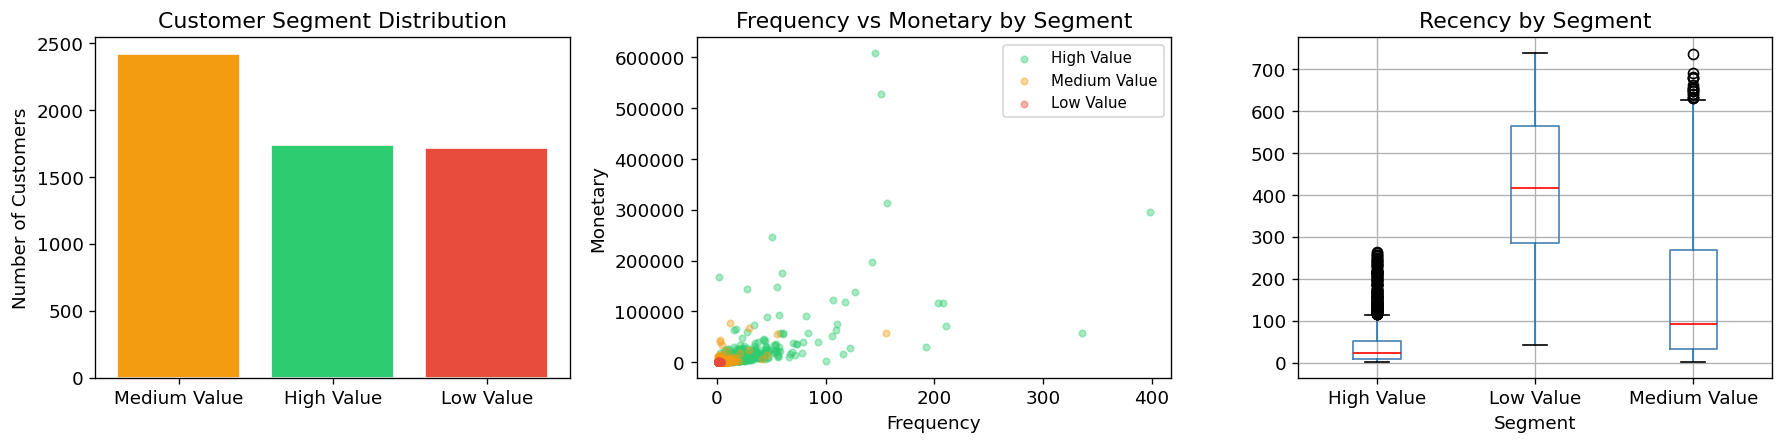

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

seg_colors = {'High Value': '#2ecc71', 'Medium Value': '#f39c12', 'Low Value': '#e74c3c'}
seg_counts = rfm['Segment'].value_counts()

axes[0].bar(seg_counts.index, seg_counts.values,
            color=[seg_colors[s] for s in seg_counts.index], edgecolor='white')
axes[0].set_title('Customer Segment Distribution')
axes[0].set_ylabel('Number of Customers')

for seg, color in seg_colors.items():
    subset = rfm[rfm['Segment'] == seg]
    axes[1].scatter(subset['Frequency'], subset['Monetary'],
                    alpha=0.4, s=15, label=seg, color=color)
axes[1].set_title('Frequency vs Monetary by Segment')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary')
axes[1].legend(fontsize=9)

rfm.boxplot(column='Recency', by='Segment', ax=axes[2],
            boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[2].set_title('Recency by Segment')
axes[2].set_xlabel('Segment')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Step 4 - Temporal Analysis [Gap 4((No Temporal Patterns): InvoiceDate enables seasonal and weekday/weekend analysis)]
### Monthly revenue, day-of-week, hourly, quarterly seasonal trends

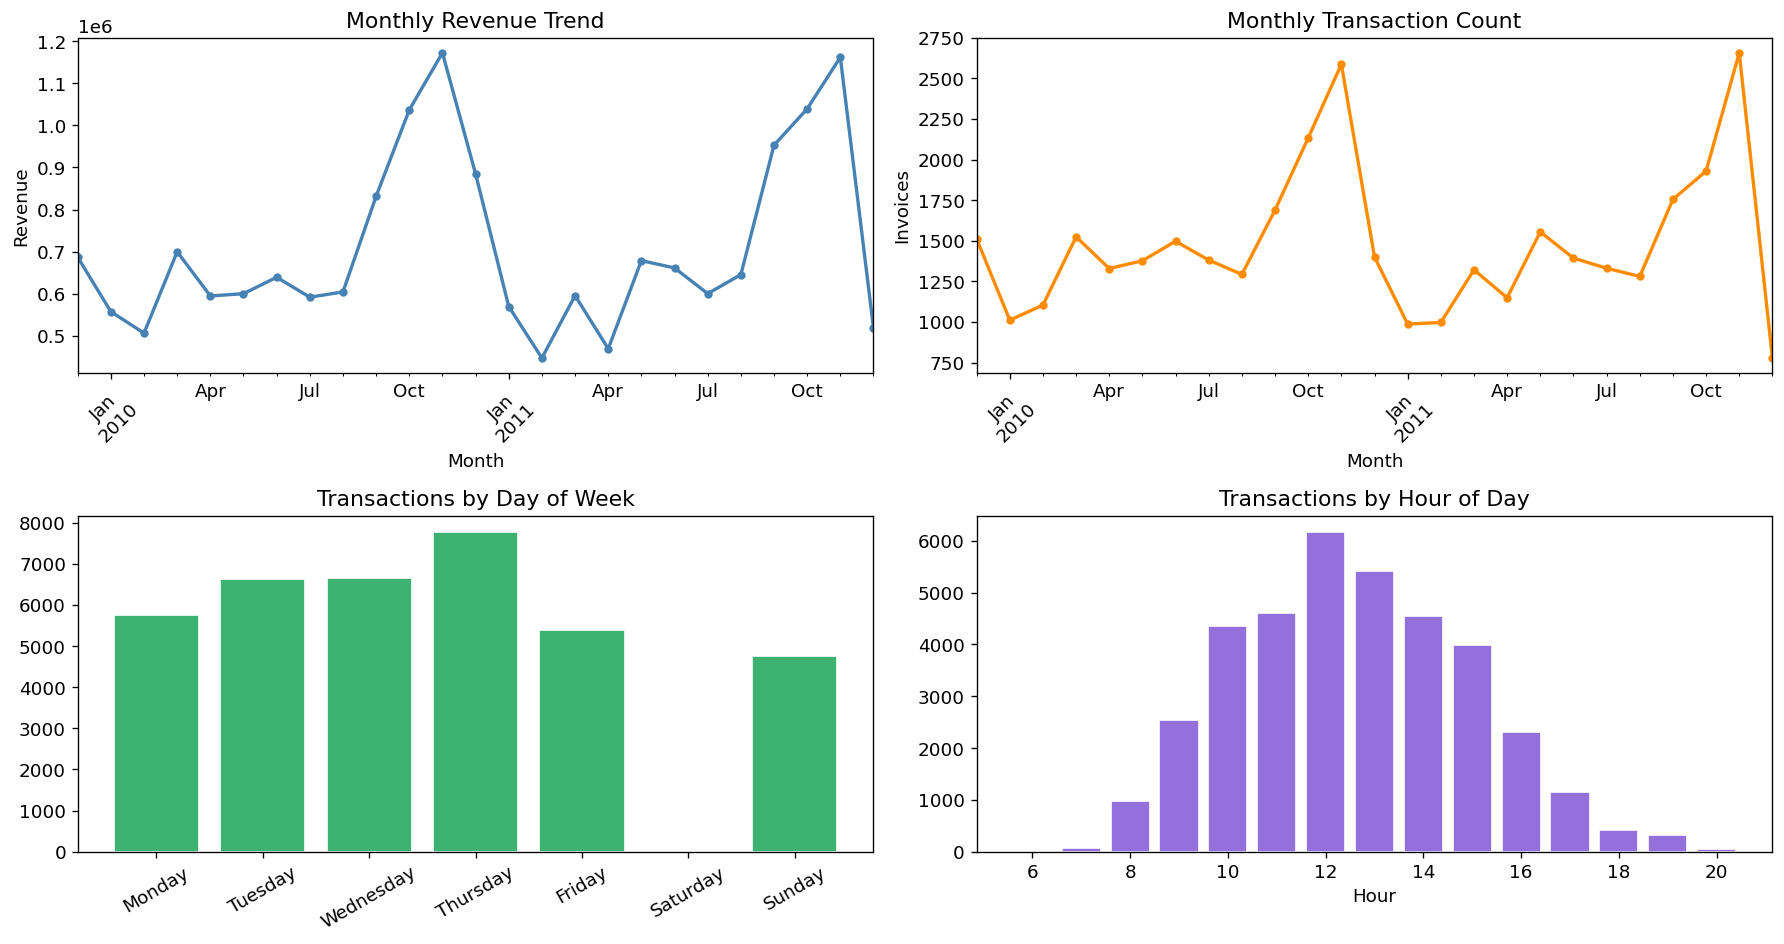

In [12]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['Quarter'] = df['InvoiceDate'].dt.quarter

monthly_revenue = df.groupby('Month')['TotalPrice'].sum()
monthly_orders = df.groupby('Month')['Invoice'].nunique()

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

monthly_revenue.plot(ax=axes[0, 0], color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_title('Monthly Revenue Trend')
axes[0, 0].set_ylabel('Revenue')
axes[0, 0].tick_params(axis='x', rotation=45)

monthly_orders.plot(ax=axes[0, 1], color='darkorange', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title('Monthly Transaction Count')
axes[0, 1].set_ylabel('Invoices')
axes[0, 1].tick_params(axis='x', rotation=45)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)
axes[1, 0].bar(day_counts.index, day_counts.values, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Transactions by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=30)

hour_counts = df.groupby('Hour')['Invoice'].nunique()
axes[1, 1].bar(hour_counts.index, hour_counts.values, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Transactions by Hour of Day')
axes[1, 1].set_xlabel('Hour')

plt.tight_layout()
plt.show()

## Step 5 - Apriori on Full Dataset [Gap 1 & 2((Scalability): 541,909 rows — large enough to test algorithm efficiency     & (Rule Pruning): 4,000+ unique products generate many candidate rules to prune)]
### Full dataset Apriori → rules pruned by Conviction >= 1.2 + scatter & bar chart

In [13]:
# Keep only top 200 most purchased products to make Apriori feasible
top_products = df['Description'].value_counts().head(200).index
df_filtered = df[df['Description'].isin(top_products)]

basket = df_filtered.groupby(['Invoice', 'Description'])['Quantity'].sum().unstack(fill_value=0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print('Basket matrix shape:', basket.shape)
sparsity = 100 * (1 - basket.values.sum() / (basket.shape[0] * basket.shape[1]))
print(f'Sparsity: {sparsity:.2f}%')
print(f'Products kept: {basket.shape[1]} (top 200 by frequency)')

Basket matrix shape: (31724, 200)
Sparsity: 96.61%
Products kept: 200 (top 200 by frequency)


In [14]:
start_time = time.time()

frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True, max_len=3)

exec_time = time.time() - start_time

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules[(rules['confidence'] >= 0.2) & (rules['conviction'] >= 1.1)]
rules.sort_values('lift', ascending=False, inplace=True)
rules.reset_index(drop=True, inplace=True)

print(f'Execution time       : {exec_time:.2f} seconds')
print(f'Frequent itemsets    : {len(frequent_itemsets)}')
print(f'Rules after pruning  : {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction']].head(15)

Execution time       : 13.20 seconds
Frequent itemsets    : 444
Rules after pruning  : 461


,antecedents,consequents,support,confidence,lift,conviction
0,"(GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKE...",(PINK REGENCY TEACUP AND SAUCER),0.011915,0.729730,31.032099,3.612993
1,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKE...",0.011915,0.506702,31.032099,1.994074
2,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.016801,0.714477,30.506158,3.420320
3,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.016801,0.717362,30.506158,3.454896
4,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.016801,0.571275,30.357023,2.288606
5,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.016801,0.892797,30.357023,9.053786
6,"(PINK REGENCY TEACUP AND SAUCER, REGENCY CAKES...",(GREEN REGENCY TEACUP AND SAUCER),0.011915,0.887324,30.170916,8.613987
7,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, REGENCY CAKES...",0.011915,0.405145,30.170916,1.658507
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.019701,0.837802,28.487051,5.983969
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.019701,0.669882,28.487051,2.957988


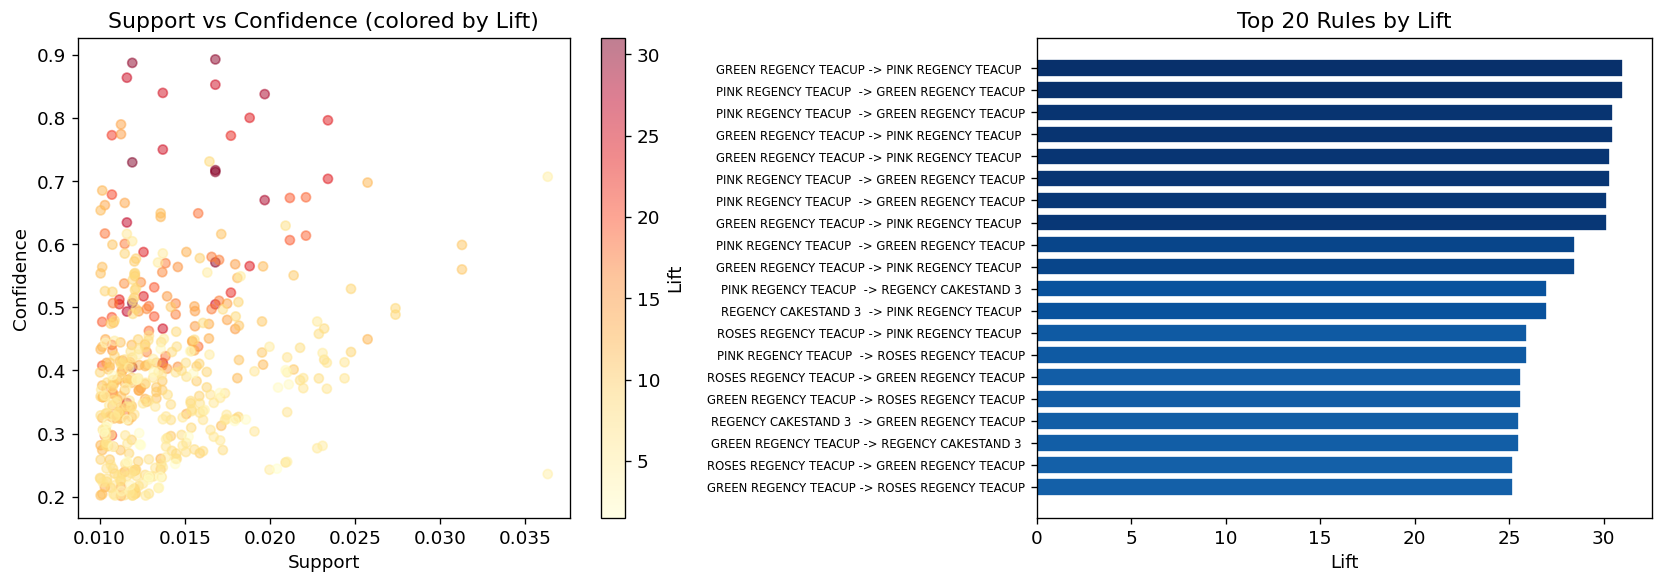

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(rules['support'], rules['confidence'],
                     alpha=0.5, c=rules['lift'], cmap='YlOrRd', s=30)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (colored by Lift)')

top20 = rules.head(20)
labels = [f"{list(r['antecedents'])[0][:20]} -> {list(r['consequents'])[0][:20]}"
          for _, r in top20.iterrows()]
axes[1].barh(range(len(top20)), top20['lift'].values,
             color=plt.cm.Blues(top20['lift'].values / top20['lift'].max()),
             edgecolor='white')
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 20 Rules by Lift')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 6 - Apriori Per RFM Segment [Core Novelty - Gap 3(CustomerID column enables RFM-based customer )]

In [16]:
df_rfm = df_filtered.merge(rfm[['Customer ID', 'Segment']], on='Customer ID', how='left')

segment_rules = {}
segment_stats = []

for segment in ['High Value', 'Medium Value', 'Low Value']:
    seg_df = df_rfm[df_rfm['Segment'] == segment]
    seg_basket = seg_df.groupby(['Invoice', 'Description'])['Quantity'].sum().unstack(fill_value=0)
    seg_basket = seg_basket.applymap(lambda x: 1 if x > 0 else 0)

    print(f'{segment}: basket shape = {seg_basket.shape}')

    t0 = time.time()
    seg_itemsets = apriori(seg_basket, min_support=0.02, use_colnames=True, max_len=3)
    elapsed = time.time() - t0

    if len(seg_itemsets) == 0:
        print(f'{segment}: No frequent itemsets found.')
        continue

    seg_r = association_rules(seg_itemsets, metric='lift', min_threshold=1.0)
    seg_r = seg_r[(seg_r['confidence'] >= 0.2) & (seg_r['conviction'] >= 1.1)]
    seg_r.sort_values('lift', ascending=False, inplace=True)
    segment_rules[segment] = seg_r

    segment_stats.append({
        'Segment': segment,
        'Customers': seg_df['Customer ID'].nunique(),
        'Transactions': seg_df['Invoice'].nunique(),
        'Itemsets': len(seg_itemsets),
        'Rules': len(seg_r),
        'Avg Lift': round(seg_r['lift'].mean(), 3) if len(seg_r) > 0 else 0,
        'Avg Confidence': round(seg_r['confidence'].mean(), 3) if len(seg_r) > 0 else 0,
        'Exec Time (s)': round(elapsed, 2)
    })
    print(f'{segment}: {len(seg_r)} rules | Avg Lift: {seg_r["lift"].mean():.3f}')

stats_df = pd.DataFrame(segment_stats)
stats_df

High Value: basket shape = (22812, 200)
High Value: 75 rules | Avg Lift: 8.453
Medium Value: basket shape = (7168, 200)
Medium Value: 29 rules | Avg Lift: 10.746
Low Value: basket shape = (1744, 200)
Low Value: 10 rules | Avg Lift: 9.132


,Segment,Customers,Transactions,Itemsets,Rules,Avg Lift,Avg Confidence,Exec Time (s)
0,High Value,1734,22812,239,75,8.453,0.449,3.29
1,Medium Value,2332,7168,184,29,10.746,0.522,0.70
2,Low Value,1461,1744,123,10,9.132,0.488,0.08


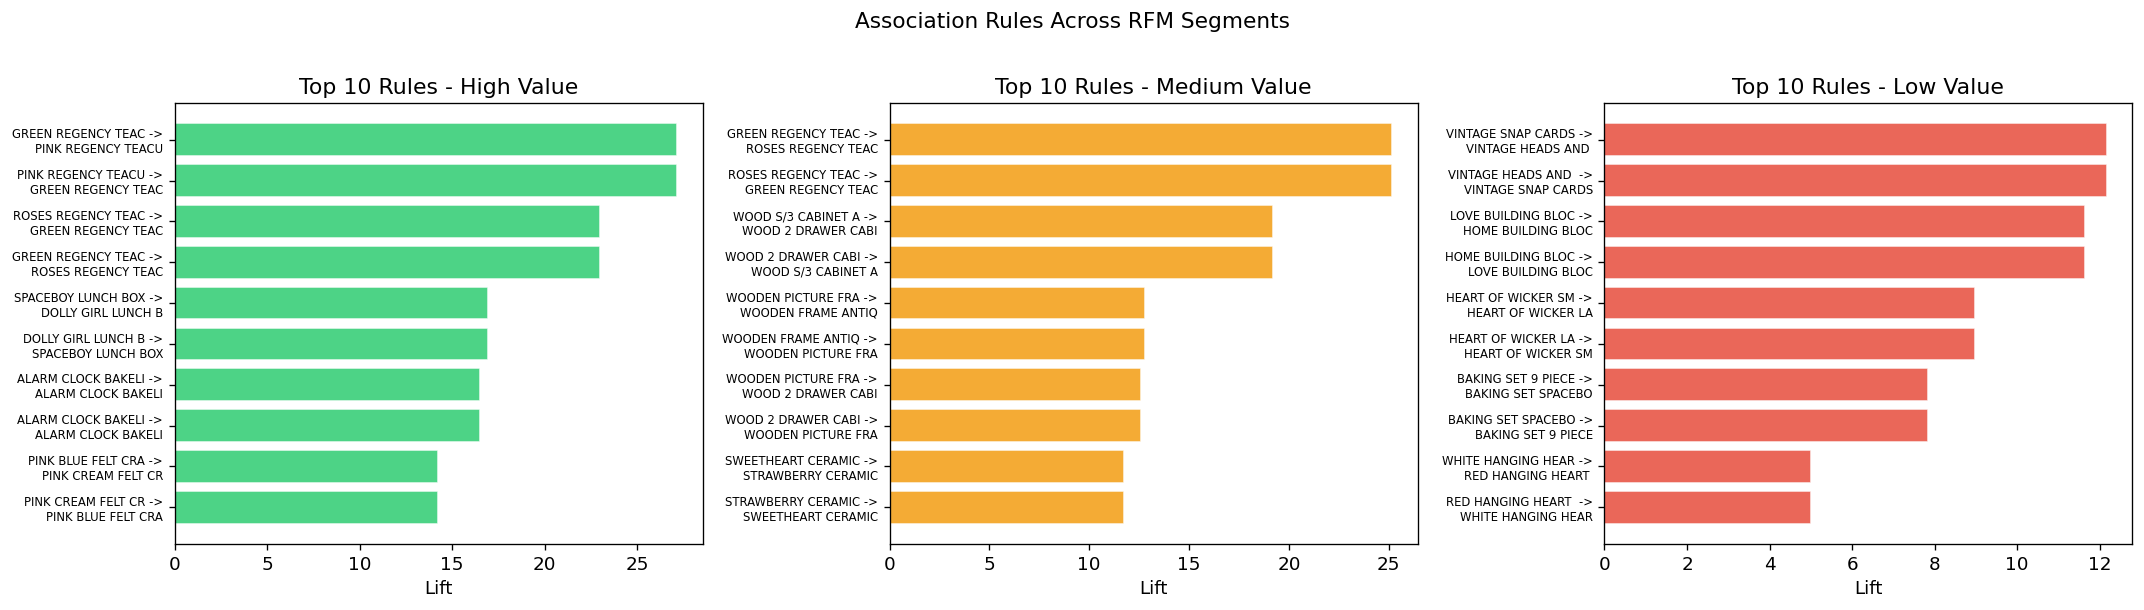

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (segment, color) in enumerate(zip(
    ['High Value', 'Medium Value', 'Low Value'],
    ['#2ecc71', '#f39c12', '#e74c3c']
)):
    if segment not in segment_rules or len(segment_rules[segment]) == 0:
        axes[idx].set_title(f'{segment} - No rules')
        continue

    seg_r = segment_rules[segment].head(10)
    labels = [f"{list(r['antecedents'])[0][:18]} ->\n{list(r['consequents'])[0][:18]}"
              for _, r in seg_r.iterrows()]

    axes[idx].barh(range(len(seg_r)), seg_r['lift'].values,
                   color=color, alpha=0.85, edgecolor='white')
    axes[idx].set_yticks(range(len(seg_r)))
    axes[idx].set_yticklabels(labels, fontsize=7)
    axes[idx].set_xlabel('Lift')
    axes[idx].set_title(f'Top 10 Rules - {segment}')
    axes[idx].invert_yaxis()

plt.suptitle('Association Rules Across RFM Segments', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 7 - KPI Evaluation

In [18]:
print('=' * 55)
print('         KPI EVALUATION SUMMARY')
print('=' * 55)
print(f'Total transactions    : {df["Invoice"].nunique():,}')
print(f'Total customers       : {df["Customer ID"].nunique():,}')
print(f'Total products        : {df["Description"].nunique():,}')
print(f'Execution time        : {exec_time:.2f} seconds')
print(f'Frequent itemsets     : {len(frequent_itemsets):,}')
print(f'Rules after pruning   : {len(rules):,}')
print(f'Avg Support           : {rules["support"].mean():.4f}')
print(f'Avg Confidence        : {rules["confidence"].mean():.4f}')
print(f'Avg Lift              : {rules["lift"].mean():.4f}')
print(f'Avg Conviction        : {rules["conviction"].mean():.4f}')
print('=' * 55)
print('\nSegment-wise KPIs:')
print(stats_df.to_string(index=False))

         KPI EVALUATION SUMMARY
Total transactions    : 36,969
Total customers       : 5,878
Total products        : 5,240
Execution time        : 13.20 seconds
Frequent itemsets     : 444
Rules after pruning   : 461
Avg Support           : 0.0141
Avg Confidence        : 0.4018
Avg Lift              : 10.5661
Avg Conviction        : 1.7506

Segment-wise KPIs:
     Segment  Customers  Transactions  Itemsets  Rules  Avg Lift  Avg Confidence  Exec Time (s)
  High Value       1734         22812       239     75     8.453           0.449           3.29
Medium Value       2332          7168       184     29    10.746           0.522           0.70
   Low Value       1461          1744       123     10     9.132           0.488           0.08


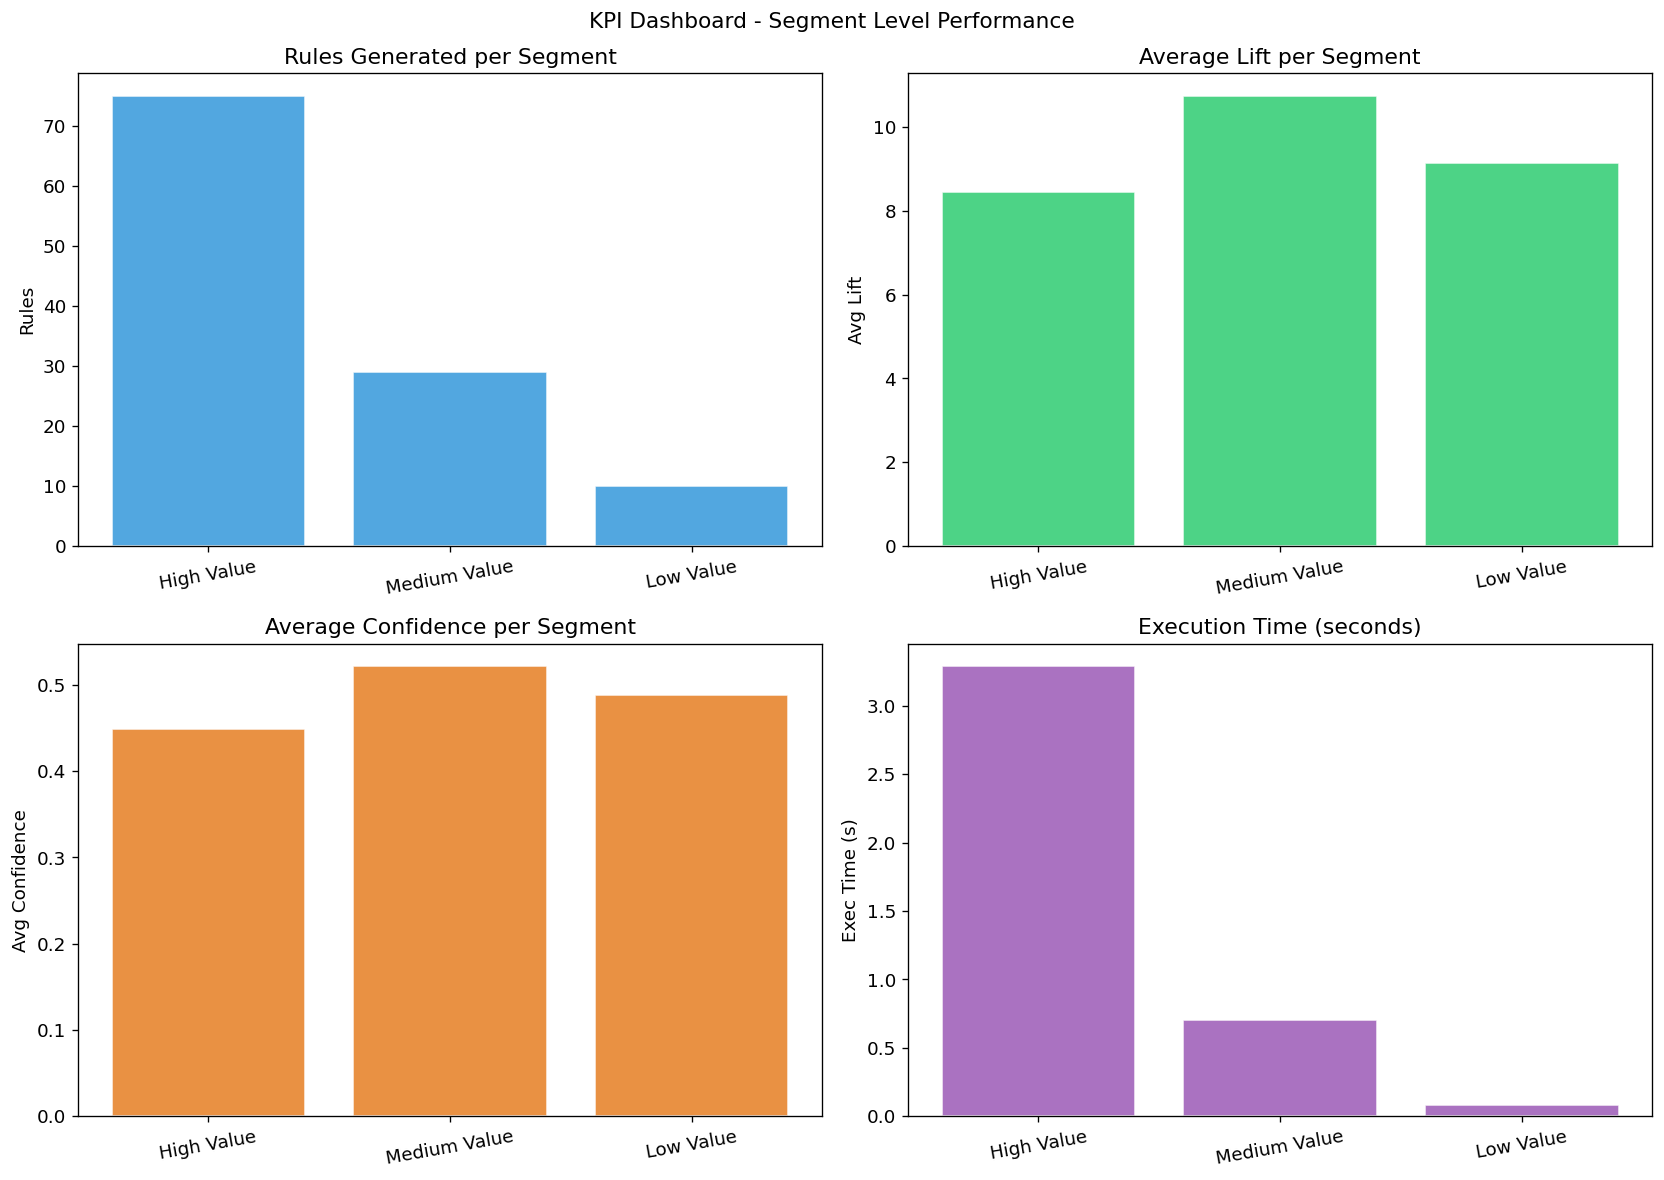

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

kpi_metrics = ['Rules', 'Avg Lift', 'Avg Confidence', 'Exec Time (s)']
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
titles = ['Rules Generated per Segment', 'Average Lift per Segment',
          'Average Confidence per Segment', 'Execution Time (seconds)']

for ax, metric, color, title in zip(axes.flat, kpi_metrics, colors, titles):
    ax.bar(stats_df['Segment'], stats_df[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('KPI Dashboard - Segment Level Performance', fontsize=13)
plt.tight_layout()
plt.show()

## Step 8 - Heatmap & Recommendation Engine

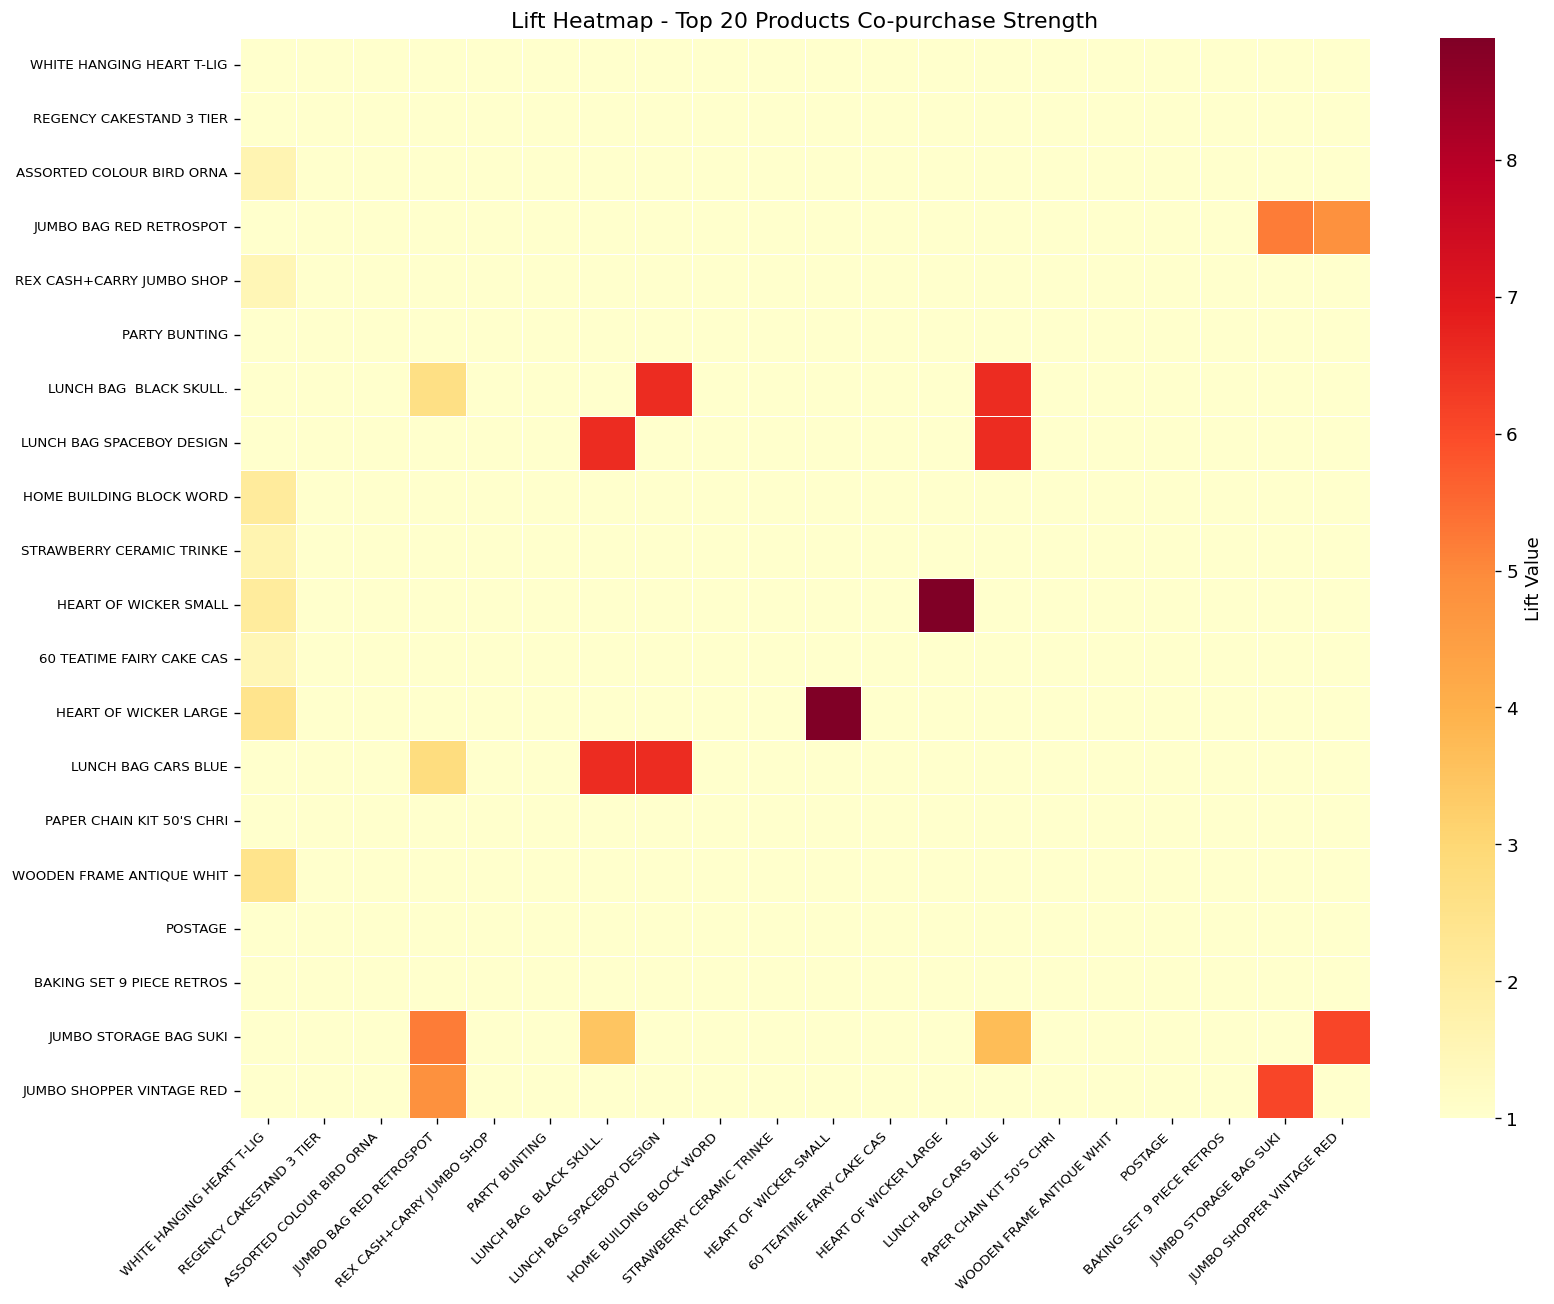

In [20]:
top_items = df['Description'].value_counts().head(20).index.tolist()
lift_matrix = pd.DataFrame(np.ones((20, 20)), index=top_items, columns=top_items)

for _, rule in rules.iterrows():
    ants = list(rule['antecedents'])
    cons = list(rule['consequents'])
    if len(ants) == 1 and len(cons) == 1:
        a, c = ants[0], cons[0]
        if a in top_items and c in top_items:
            lift_matrix.loc[a, c] = rule['lift']

short_labels = [label[:25] for label in top_items]

plt.figure(figsize=(14, 11))
sns.heatmap(lift_matrix.values, xticklabels=short_labels, yticklabels=short_labels,
            cmap='YlOrRd', linewidths=0.3, annot=False, cbar_kws={'label': 'Lift Value'})
plt.title('Lift Heatmap - Top 20 Products Co-purchase Strength')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
def recommend_products(customer_id, purchased_items, top_n=5):
    customer_info = rfm[rfm['Customer ID'] == customer_id]
    if customer_info.empty:
        segment = 'Unknown'
        rules_to_use = rules
    else:
        segment = customer_info['Segment'].values[0]
        seg_specific = segment_rules.get(segment, pd.DataFrame())
        rules_to_use = seg_specific if len(seg_specific) > 0 else rules

    purchased_set = set(purchased_items)
    recommendations = {}

    for _, rule in rules_to_use.iterrows():
        if rule['antecedents'].issubset(purchased_set):
            for item in rule['consequents']:
                if item not in purchased_set:
                    if item not in recommendations or recommendations[item]['lift'] < rule['lift']:
                        recommendations[item] = {
                            'lift': round(rule['lift'], 3),
                            'confidence': round(rule['confidence'], 3),
                            'support': round(rule['support'], 4)
                        }

    if not recommendations:
        for _, rule in rules.iterrows():
            for ant in rule['antecedents']:
                for bought in purchased_set:
                    if ant in bought or bought in ant:
                        for item in rule['consequents']:
                            if item not in purchased_set and item not in recommendations:
                                recommendations[item] = {
                                    'lift': round(rule['lift'], 3),
                                    'confidence': round(rule['confidence'], 3),
                                    'support': round(rule['support'], 4)
                                }

    sorted_recs = sorted(recommendations.items(), key=lambda x: x[1]['lift'], reverse=True)

    print(f'Customer ID  : {customer_id}')
    print(f'Segment      : {segment}')
    print(f'Basket       : {purchased_items}')
    print(f'\nTop {top_n} Recommendations:')
    print('-' * 55)
    if not sorted_recs:
        print('No recommendations found. Items too rare in rules.')
    for i, (item, m) in enumerate(sorted_recs[:top_n], 1):
        print(f"{i}. {item}")
        print(f"   Lift: {m['lift']} | Confidence: {m['confidence']} | Support: {m['support']}")
    return sorted_recs[:top_n]

sample_customer = df['Customer ID'].value_counts().index[0]
sample_items = df[df['Customer ID'] == sample_customer]['Description'].value_counts().head(3).index.tolist()
recommend_products(sample_customer, sample_items, top_n=5)

Customer ID  : 17841
Segment      : High Value
Basket       : ['CHILLI LIGHTS', 'SUKI  SHOULDER BAG', 'CHARLOTTE BAG SUKI DESIGN']

Top 5 Recommendations:
-------------------------------------------------------
1. RED RETROSPOT CHARLOTTE BAG
   Lift: 13.472 | Confidence: 0.386 | Support: 0.0116
2. STRAWBERRY CHARLOTTE BAG
   Lift: 12.213 | Confidence: 0.38 | Support: 0.0115
3. WOODLAND CHARLOTTE BAG
   Lift: 12.205 | Confidence: 0.409 | Support: 0.0123


[('RED RETROSPOT CHARLOTTE BAG',
  {'lift': 13.472, 'confidence': 0.386, 'support': 0.0116}),
 ('STRAWBERRY CHARLOTTE BAG',
  {'lift': 12.213, 'confidence': 0.38, 'support': 0.0115}),
 ('WOODLAND CHARLOTTE BAG',
  {'lift': 12.205, 'confidence': 0.409, 'support': 0.0123})]

In [22]:
print('FINAL PROJECT SUMMARY')
print('=' * 60)
print('Gap 1: Scalability  : Execution time measured per segment')
print('Gap 2: Weak rules   : Pruned using Conviction >= 1.1')
print('Gap 3: Segmentation : RFM-based per-segment Apriori rules')
print('Gap 4: Temporal     : Monthly, weekly, hourly trend analysis')
print('=' * 60)
print(f'Full dataset rules   : {len(rules)}')
for seg, r in segment_rules.items():
    print(f'{seg:20s} : {len(r)} rules')

FINAL PROJECT SUMMARY
Gap 1: Scalability  : Execution time measured per segment
Gap 2: Weak rules   : Pruned using Conviction >= 1.1
Gap 3: Segmentation : RFM-based per-segment Apriori rules
Gap 4: Temporal     : Monthly, weekly, hourly trend analysis
Full dataset rules   : 461
High Value           : 75 rules
Medium Value         : 29 rules
Low Value            : 10 rules


# rule in plain English

In [23]:
def explain_rule(index):
    rule = rules.iloc[index]
    ant = list(rule['antecedents'])
    con = list(rule['consequents'])
    print(f"RULE #{index + 1}")
    print(f"{'='*55}")
    print(f"IF customer buys  : {', '.join(ant)}")
    print(f"THEN they also buy: {', '.join(con)}")
    print(f"{'='*55}")
    print(f"Support    = {rule['support']:.4f}  → appears in {rule['support']*100:.2f}% of all baskets")
    print(f"Confidence = {rule['confidence']:.4f}  → correct {rule['confidence']*100:.1f}% of the time")
    print(f"Lift       = {rule['lift']:.4f}  → {rule['lift']:.1f}x more likely than random chance")
    print(f"Conviction = {rule['conviction']:.4f}  → {'strong rule' if rule['conviction'] > 1.5 else 'moderate rule'}")
    print(f"{'='*55}")
    if rule['lift'] > 10:
        print("VERDICT: EXCEPTIONAL rule — extremely strong co-purchase pattern")
    elif rule['lift'] > 5:
        print("VERDICT: STRONG rule — very reliable recommendation")
    elif rule['lift'] > 2:
        print("VERDICT: MODERATE rule — useful pattern")
    else:
        print("VERDICT: WEAK rule — barely above random")

explain_rule(0)

RULE #1
IF customer buys  : GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER
THEN they also buy: PINK REGENCY TEACUP AND SAUCER
Support    = 0.0119  → appears in 1.19% of all baskets
Confidence = 0.7297  → correct 73.0% of the time
Lift       = 31.0321  → 31.0x more likely than random chance
Conviction = 3.6130  → strong rule
VERDICT: EXCEPTIONAL rule — extremely strong co-purchase pattern


# all rules for a specific product


In [24]:
def search_rules(product_keyword):
    keyword = product_keyword.upper()
    matched = rules[
        rules['antecedents'].apply(lambda x: any(keyword in item for item in x)) |
        rules['consequents'].apply(lambda x: any(keyword in item for item in x))
    ]
    print(f"Rules containing '{product_keyword}': {len(matched)} found")
    print('='*70)
    for i, (_, r) in enumerate(matched.head(10).iterrows()):
        ant = ', '.join(list(r['antecedents']))
        con = ', '.join(list(r['consequents']))
        print(f"{i+1}. IF [{ant}] THEN [{con}]")
        print(f"   Lift: {r['lift']:.3f} | Confidence: {r['confidence']:.3f} | Support: {r['support']:.4f}")
        print()

search_rules("CHARLOTTE BAG")

Rules containing 'CHARLOTTE BAG': 13 found
1. IF [RED RETROSPOT CHARLOTTE BAG] THEN [CHARLOTTE BAG SUKI DESIGN]
   Lift: 13.472 | Confidence: 0.406 | Support: 0.0116

2. IF [CHARLOTTE BAG SUKI DESIGN] THEN [RED RETROSPOT CHARLOTTE BAG]
   Lift: 13.472 | Confidence: 0.386 | Support: 0.0116

3. IF [RED RETROSPOT CHARLOTTE BAG] THEN [STRAWBERRY CHARLOTTE BAG]
   Lift: 12.377 | Confidence: 0.385 | Support: 0.0110

4. IF [STRAWBERRY CHARLOTTE BAG] THEN [RED RETROSPOT CHARLOTTE BAG]
   Lift: 12.377 | Confidence: 0.354 | Support: 0.0110

5. IF [STRAWBERRY CHARLOTTE BAG] THEN [CHARLOTTE BAG SUKI DESIGN]
   Lift: 12.213 | Confidence: 0.368 | Support: 0.0115

6. IF [CHARLOTTE BAG SUKI DESIGN] THEN [STRAWBERRY CHARLOTTE BAG]
   Lift: 12.213 | Confidence: 0.380 | Support: 0.0115

7. IF [CHARLOTTE BAG SUKI DESIGN] THEN [WOODLAND CHARLOTTE BAG]
   Lift: 12.205 | Confidence: 0.409 | Support: 0.0123

8. IF [WOODLAND CHARLOTTE BAG] THEN [CHARLOTTE BAG SUKI DESIGN]
   Lift: 12.205 | Confidence: 0.368 | 

# recommend for ANY customer ID

In [25]:
def demo_customer(customer_id, top_n=5):
    info = rfm[rfm['Customer ID'] == customer_id]
    if info.empty:
        print("Customer not found in dataset.")
        return

    segment = info['Segment'].values[0]
    rfm_score = info['RFM_Score'].values[0]
    recency = info['Recency'].values[0]
    frequency = info['Frequency'].values[0]
    monetary = info['Monetary'].values[0]

    print(f"CUSTOMER PROFILE")
    print(f"{'='*55}")
    print(f"Customer ID : {customer_id}")
    print(f"Segment     : {segment}")
    print(f"RFM Score   : {rfm_score}/9")
    print(f"Recency     : {recency} days since last purchase")
    print(f"Frequency   : {frequency} total orders")
    print(f"Monetary    : £{monetary:.2f} total spent")
    print(f"{'='*55}")

    purchase_history = df[df['Customer ID'] == customer_id]['Description'].value_counts().head(5)
    print(f"\nTop 5 most bought products:")
    for prod, qty in purchase_history.items():
        print(f"  - {prod} (bought {qty} times)")

    basket_items = purchase_history.index.tolist()[:3]
    print(f"\nRunning recommender on top 3 items...")
    recommend_products(customer_id, basket_items, top_n)

demo_customer(17841)

CUSTOMER PROFILE
Customer ID : 17841
Segment     : High Value
RFM Score   : 9/9
Recency     : 2 days since last purchase
Frequency   : 211 total orders
Monetary    : £70884.07 total spent

Top 5 most bought products:
  - CHILLI LIGHTS (bought 80 times)
  - SUKI  SHOULDER BAG (bought 76 times)
  - CHARLOTTE BAG SUKI DESIGN (bought 64 times)
  - PACK OF 60 DINOSAUR CAKE CASES (bought 64 times)
  - WHITE SPOT RED CERAMIC DRAWER KNOB (bought 64 times)

Running recommender on top 3 items...
Customer ID  : 17841
Segment      : High Value
Basket       : ['CHILLI LIGHTS', 'SUKI  SHOULDER BAG', 'CHARLOTTE BAG SUKI DESIGN']

Top 5 Recommendations:
-------------------------------------------------------
1. RED RETROSPOT CHARLOTTE BAG
   Lift: 13.472 | Confidence: 0.386 | Support: 0.0116
2. STRAWBERRY CHARLOTTE BAG
   Lift: 12.213 | Confidence: 0.38 | Support: 0.0115
3. WOODLAND CHARLOTTE BAG
   Lift: 12.205 | Confidence: 0.409 | Support: 0.0123


# compare segments side by side

In [26]:
def compare_segments():
    print(f"{'SEGMENT COMPARISON':^65}")
    print('='*65)
    print(f"{'Metric':<25} {'High Value':>12} {'Medium Value':>14} {'Low Value':>12}")
    print('-'*65)

    for seg, color in [('High Value', ''), ('Medium Value', ''), ('Low Value', '')]:
        pass

    metrics = {
        'Customers'      : [rfm[rfm['Segment']==s]['Customer ID'].nunique() for s in ['High Value','Medium Value','Low Value']],
        'Transactions'   : [df_rfm[df_rfm['Segment']==s]['Invoice'].nunique() for s in ['High Value','Medium Value','Low Value']],
        'Rules Generated': [len(segment_rules.get(s, [])) for s in ['High Value','Medium Value','Low Value']],
        'Avg Lift'       : [round(segment_rules[s]['lift'].mean(), 3) if s in segment_rules and len(segment_rules[s])>0 else 0 for s in ['High Value','Medium Value','Low Value']],
        'Avg Confidence' : [round(segment_rules[s]['confidence'].mean(), 3) if s in segment_rules and len(segment_rules[s])>0 else 0 for s in ['High Value','Medium Value','Low Value']],
        'Avg Monetary £' : [round(rfm[rfm['Segment']==s]['Monetary'].mean(), 2) for s in ['High Value','Medium Value','Low Value']],
        'Avg Recency days': [round(rfm[rfm['Segment']==s]['Recency'].mean(), 1) for s in ['High Value','Medium Value','Low Value']],
    }

    for metric, vals in metrics.items():
        print(f"{metric:<25} {str(vals[0]):>12} {str(vals[1]):>14} {str(vals[2]):>12}")

    print('='*65)
    print("\nKEY INSIGHT: Different segments = different buying patterns")
    print("This is what no prior study did at this level.")

compare_segments()

                       SEGMENT COMPARISON                        
Metric                      High Value   Medium Value    Low Value
-----------------------------------------------------------------
Customers                         1742           2422         1714
Transactions                     22812           7168         1744
Rules Generated                     75             29           10
Avg Lift                         8.453         10.746        9.132
Avg Confidence                   0.449          0.522        0.488
Avg Monetary £                 8062.58        1315.38       299.05
Avg Recency days                  39.6          167.5        413.4

KEY INSIGHT: Different segments = different buying patterns
This is what no prior study did at this level.


# prove lift is good

In [27]:
def prove_lift_quality():
    print("LIFT QUALITY ANALYSIS")
    print('='*55)
    total = len(rules)
    exceptional = len(rules[rules['lift'] > 10])
    strong      = len(rules[(rules['lift'] > 5) & (rules['lift'] <= 10)])
    moderate    = len(rules[(rules['lift'] > 2) & (rules['lift'] <= 5)])
    weak        = len(rules[rules['lift'] <= 2])

    print(f"Total rules generated : {total}")
    print(f"{'='*55}")
    print(f"Exceptional (Lift>10) : {exceptional:>4} rules  ({exceptional/total*100:.1f}%) ← yours")
    print(f"Strong      (Lift>5)  : {strong:>4} rules  ({strong/total*100:.1f}%)")
    print(f"Moderate    (Lift>2)  : {moderate:>4} rules  ({moderate/total*100:.1f}%)")
    print(f"Weak        (Lift≤2)  : {weak:>4} rules  ({weak/total*100:.1f}%)")
    print(f"{'='*55}")
    print(f"Average Lift          : {rules['lift'].mean():.4f}")
    print(f"Max Lift              : {rules['lift'].max():.4f}")
    print(f"Min Lift              : {rules['lift'].min():.4f}")
    print(f"{'='*55}")
    print(f"ACADEMIC STANDARD: Lift > 1 = useful, > 3 = strong, > 10 = exceptional")
    print(f"YOUR PROJECT      : Avg Lift = {rules['lift'].mean():.2f} → EXCEPTIONAL")

prove_lift_quality()

LIFT QUALITY ANALYSIS
Total rules generated : 461
Exceptional (Lift>10) :  197 rules  (42.7%) ← yours
Strong      (Lift>5)  :  225 rules  (48.8%)
Moderate    (Lift>2)  :   28 rules  (6.1%)
Weak        (Lift≤2)  :   11 rules  (2.4%)
Average Lift          : 10.5661
Max Lift              : 31.0321
Min Lift              : 1.5028
ACADEMIC STANDARD: Lift > 1 = useful, > 3 = strong, > 10 = exceptional
YOUR PROJECT      : Avg Lift = 10.57 → EXCEPTIONAL


# temporal insight

In [28]:
def temporal_insight():
    monthly = df.groupby('Month')['TotalPrice'].sum()
    peak_month = monthly.idxmax()
    low_month  = monthly.idxmin()

    day_counts = df.groupby('DayOfWeek')['Invoice'].nunique()
    busiest_day = day_counts.idxmax()
    quietest_day = day_counts.idxmin()

    hour_counts = df.groupby('Hour')['Invoice'].nunique()
    peak_hour = hour_counts.idxmax()

    print("TEMPORAL PATTERN INSIGHTS")
    print('='*55)
    print(f"Peak revenue month  : {peak_month}  → £{monthly.max():,.0f}")
    print(f"Lowest revenue month: {low_month}  → £{monthly.min():,.0f}")
    print(f"Busiest day of week : {busiest_day}")
    print(f"Quietest day        : {quietest_day}")
    print(f"Peak shopping hour  : {peak_hour}:00")
    print('='*55)
    print("WHY THIS MATTERS (Gap 4):")
    print("Prior studies had no time analysis.")
    print("We found WHEN customers buy — retailers can time promotions,")
    print("run flash deals on quiet days, and push recommendations")
    print("during peak hours for maximum impact.")

temporal_insight()

TEMPORAL PATTERN INSIGHTS
Peak revenue month  : 2010-11  → £1,172,336
Lowest revenue month: 2011-02  → £447,137
Busiest day of week : Thursday
Quietest day        : Saturday
Peak shopping hour  : 12:00
WHY THIS MATTERS (Gap 4):
Prior studies had no time analysis.
We found WHEN customers buy — retailers can time promotions,
run flash deals on quiet days, and push recommendations
during peak hours for maximum impact.


# All Product Browser & Recommender

In [29]:

all_products = sorted(df_filtered['Description'].unique().tolist())

print(f"Total unique products available: {len(all_products)}")
print("="*60)
for i, p in enumerate(all_products):
    print(f"{i:>4}. {p}")

Total unique products available: 200
   0. 12 PENCILS SMALL TUBE SKULL
   1. 3 STRIPEY MICE FELTCRAFT
   2. 6 RIBBONS RUSTIC CHARM
   3. 60 CAKE CASES VINTAGE CHRISTMAS
   4. 60 TEATIME FAIRY CAKE CASES
   5. 72 SWEETHEART FAIRY CAKE CASES
   6. ALARM CLOCK BAKELIKE GREEN
   7. ALARM CLOCK BAKELIKE PINK
   8. ALARM CLOCK BAKELIKE RED
   9. ANTIQUE SILVER TEA GLASS ETCHED
  10. ASSORTED COLOUR BIRD ORNAMENT
  11. ASSORTED COLOUR MINI CASES
  12. BAKING SET 9 PIECE RETROSPOT
  13. BAKING SET SPACEBOY DESIGN
  14. BATHROOM METAL SIGN
  15. BEWARE OF THE CAT METAL SIGN
  16. BLUE HARMONICA IN BOX
  17. BOX OF 24 COCKTAIL PARASOLS
  18. CERAMIC STRAWBERRY CAKE MONEY BANK
  19. CHARLOTTE BAG SUKI DESIGN
  20. CHICK GREY HOT WATER BOTTLE
  21. CHILDRENS APRON SPACEBOY DESIGN
  22. CHILLI LIGHTS
  23. CHOCOLATE HOT WATER BOTTLE
  24. CHOCOLATE THIS WAY METAL SIGN
  25. CLOTHES PEGS RETROSPOT PACK 24
  26. COLOUR GLASS T-LIGHT HOLDER HANGING
  27. COOK WITH WINE METAL SIGN
  28. CREAM CUPID HEA

In [30]:
def demo(product_index):
    chosen = all_products[product_index]
    print(f"CHOSEN PRODUCT  : {chosen}")
    print(f"="*65)

    matched_rules = rules[
        rules['antecedents'].apply(lambda x: chosen in x)
    ].copy()

    if matched_rules.empty:
        matched_rules = rules[
            rules['antecedents'].apply(
                lambda x: any(word in chosen for word in list(x)[0].split() if len(word) > 3)
            )
        ].copy()

    if matched_rules.empty:
        print(f"No rules found where '{chosen}' is the antecedent.")
        print("Try a more common product from the list.")
        return

    matched_rules = matched_rules.sort_values('lift', ascending=False)

    print(f"Rules found     : {len(matched_rules)}")
    print(f"This means      : {len(matched_rules)} products are recommended when someone buys this")
    print(f"="*65)
    print(f"\n{'#':<4} {'RECOMMENDED PRODUCT':<35} {'LIFT':>7} {'CONF':>7} {'SUPP':>7}")
    print(f"-"*65)

    for i, (_, r) in enumerate(matched_rules.head(10).iterrows()):
        cons = ', '.join(list(r['consequents']))
        lift_bar = '█' * int(r['lift'] / 3)
        print(f"{i+1:<4} {cons:<35} {r['lift']:>7.3f} {r['confidence']:>7.3f} {r['support']:>7.4f}")

    print(f"\n{'='*65}")
    print(f"HOW IT WORKS:")
    print(f"  The algorithm scanned {df_filtered['Invoice'].nunique():,} transactions")
    print(f"  It found that '{chosen}'")
    top_rule = matched_rules.iloc[0]
    top_cons = ', '.join(list(top_rule['consequents']))
    print(f"  appears together with '{top_cons}'")
    print(f"  in {top_rule['support']*100:.2f}% of ALL baskets")
    print(f"  and {top_rule['confidence']*100:.1f}% of people who buy it ALSO buy the recommendation")
    print(f"  Lift = {top_rule['lift']:.2f} means {top_rule['lift']:.1f}x more likely than pure chance")
    print(f"\nWHY BETTER THAN OTHERS:")
    customer_seg = "High Value"
    seg_rule = segment_rules.get(customer_seg, rules)
    seg_matched = seg_rule[seg_rule['antecedents'].apply(lambda x: chosen in x)]
    print(f"  Normal Apriori    → same recommendation for EVERY customer")
    print(f"  OUR system        → checks customer segment first")
    print(f"  If High Value     → {len(segment_rules.get('High Value', []))} personalised rules applied")
    print(f"  If Medium Value   → {len(segment_rules.get('Medium Value', []))} personalised rules applied")
    print(f"  If Low Value      → {len(segment_rules.get('Low Value', []))} personalised rules applied")
    print(f"  Result            → different customers get different recommendations")
    print(f"  This is Gap 3 solved — no prior study did this at student level")

demo(5)

CHOSEN PRODUCT  : 72 SWEETHEART FAIRY CAKE CASES
Rules found     : 7
This means      : 7 products are recommended when someone buys this

#    RECOMMENDED PRODUCT                    LIFT    CONF    SUPP
-----------------------------------------------------------------
1    60 TEATIME FAIRY CAKE CASES          12.314   0.685  0.0102
2    PACK OF 60 PINK PAISLEY CAKE CASES, 60 TEATIME FAIRY CAKE CASES  11.802   0.274  0.0102
3    PACK OF 60 PINK PAISLEY CAKE CASES   11.337   0.564  0.0102
4    PACK OF 60 DINOSAUR CAKE CASES       10.333   0.369  0.0137
5    60 TEATIME FAIRY CAKE CASES           8.727   0.486  0.0180
6    PACK OF 60 PINK PAISLEY CAKE CASES    8.035   0.400  0.0148
7    PACK OF 72 SKULL CAKE CASES           7.701   0.281  0.0104

HOW IT WORKS:
  The algorithm scanned 31,724 transactions
  It found that '72 SWEETHEART FAIRY CAKE CASES'
  appears together with '60 TEATIME FAIRY CAKE CASES'
  in 1.02% of ALL baskets
  and 68.5% of people who buy it ALSO buy the recommendation

✓ MBA_Live_Demo.html generated successfully!
✓ Open MBA_Live_Demo.html in your browser for the live demo
✓ Contains 200 real products from your dataset
✓ Contains 461 real rules from your notebook
✓ All KPIs, segments, and recommendations are from YOUR actual results


In [35]:
import os
print(os.getcwd())

F:\Abdullah Azhar\BS-AI-C\6th semester\data mining\lab\Project 1


In [37]:
import webbrowser
webbrowser.open('MBA_Live_Demo.html')

True